In [113]:
%pip install scikit-learn
%pip install pandas
%pip install seaborn
%pip install missingno



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [114]:
import sys
print(sys.version)

3.12.1 (main, Mar 11 2026, 12:17:56) [GCC 13.3.0]


In [115]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

In [116]:
con = sqlite3.connect('ProjectData/gas_monitoring.db')

cursor = con.cursor()

        # Query the sqlite_master table to get table names
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        
        # Fetch all results
table_names = [row[0] for row in cursor.fetchall()]
query = "SELECT * FROM gas_monitoring"  # Replace 'your_table_name' with the actual table name
df = pd.read_sql_query(query, con)

CHECKING DATA

In [117]:
print(df.shape)

(10000, 14)


Table has 14 columns and 10000 rows

In [118]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time of Day                10000 non-null  str    
 1   Temperature                10000 non-null  float64
 2   Humidity                   8072 non-null   float64
 3   CO2_InfraredSensor         10000 non-null  float64
 4   CO2_ElectroChemicalSensor  10000 non-null  float64
 5   MetalOxideSensor_Unit1     10000 non-null  float64
 6   MetalOxideSensor_Unit2     8590 non-null   float64
 7   MetalOxideSensor_Unit3     10000 non-null  float64
 8   MetalOxideSensor_Unit4     10000 non-null  float64
 9   CO_GasSensor               9166 non-null   float64
 10  Session ID                 10000 non-null  int64  
 11  HVAC Operation Mode        10000 non-null  str    
 12  Ambient Light Level        8946 non-null   str    
 13  Activity Level             10000 non-null  str    
dtypes:

0. might have to standardise time of day 

1-10. Check numerics for outliers, maybe check if some readings correspond to celcius/farenheit counterpart

11-12. Make sure all modes make sense / can be turned into one-hot encode

13. needs futher exploration

In [119]:
for col in df.columns:
    print(f"--- Value Counts for {col} ---")
    print(df[col].value_counts())
    print("\n")

--- Value Counts for Time of Day ---
Time of Day
afternoon    2635
evening      2476
morning      2460
night        2429
Name: count, dtype: int64


--- Value Counts for Temperature ---
Temperature
19.460000     31
19.000000     30
19.480000     30
19.510000     26
19.450000     26
              ..
294.800000     1
27.989013      1
295.610000     1
295.670000     1
296.170000     1
Name: count, Length: 1796, dtype: int64


--- Value Counts for Humidity ---
Humidity
 52.23     18
 51.77     16
 52.91     15
 52.19     15
 52.36     15
           ..
 183.84     1
-11.60      1
-19.31      1
 120.33     1
 152.46     1
Name: count, Length: 2048, dtype: int64


--- Value Counts for CO2_InfraredSensor ---
CO2_InfraredSensor
97.651034     5
129.765286    5
134.468644    4
79.689878     4
102.762985    4
             ..
137.854649    1
131.945968    1
136.422868    1
126.734430    1
85.269262     1
Name: count, Length: 8899, dtype: int64


--- Value Counts for CO2_ElectroChemicalSensor ---
CO

Only working with time of day, no dates
There is definitely invalid values in temperature

We need to reduce decimal places

Operation mode labels need cleaning, same for activity level
threshold values: temperature, humidity and sensors

In [120]:

df[df.duplicated()].shape


(171, 14)

Number of Duplicates: 171

In [121]:
df = pd.read_sql_query(query, con)
df = df.drop_duplicates()
df = df.round(2)
print(df.shape)

(9829, 14)


In [122]:
print("number of rows with na: ", df.isna().sum().sum())
df.isna().sum()

number of rows with na:  5205


Time of Day                     0
Temperature                     0
Humidity                     1917
CO2_InfraredSensor              0
CO2_ElectroChemicalSensor       0
MetalOxideSensor_Unit1          0
MetalOxideSensor_Unit2       1406
MetalOxideSensor_Unit3          0
MetalOxideSensor_Unit4          0
CO_GasSensor                  830
Session ID                      0
HVAC Operation Mode             0
Ambient Light Level          1052
Activity Level                  0
dtype: int64

Humidity, Unit2, Light level, CO sensor have missing values with humidity having most and sensor having least

Unit2 might be faulty, check values to see if it is still reliable.

In [123]:
target_cols = ['Humidity', 'MetalOxideSensor_Unit2', 'Ambient Light Level', 'CO_GasSensor']

# 2. Count nulls across rows (axis=1) for just those columns, and filter for >= 2
df_filtered = df[df[target_cols].isnull().sum(axis=1) >= 2]

print(df_filtered.isna().sum())
print("")
print("number of rows with >1 na: ", df_filtered.isna().sum().sum())

Time of Day                    0
Temperature                    0
Humidity                     570
CO2_InfraredSensor             0
CO2_ElectroChemicalSensor      0
MetalOxideSensor_Unit1         0
MetalOxideSensor_Unit2       480
MetalOxideSensor_Unit3         0
MetalOxideSensor_Unit4         0
CO_GasSensor                 295
Session ID                     0
HVAC Operation Mode            0
Ambient Light Level          370
Activity Level                 0
dtype: int64

number of rows with >1 na:  1715


Out of the 5205 rows with error, most only have a single one null value

STANDARDISATION

In [124]:
df_standard = df.copy()
df_standard["HVAC Operation Mode"] = df_standard["HVAC Operation Mode"].str.lower().str.replace(" ", "_")
df_standard["Activity Level"] = df_standard["Activity Level"].str.replace(" ", "").str.replace("_", "")

non_numeric_cols = df_standard.select_dtypes(exclude=["number"]).columns
for col in non_numeric_cols:
    print(f"--- Value Counts for {col} ---")
    print(df_standard[col].value_counts(dropna=False))
    print("\n")

--- Value Counts for Time of Day ---
Time of Day
afternoon    2586
evening      2432
morning      2415
night        2396
Name: count, dtype: int64


--- Value Counts for HVAC Operation Mode ---
HVAC Operation Mode
cooling_active      1700
maintenance_mode    1670
eco_mode            1643
heating_active      1631
off                 1630
ventilation_only    1555
Name: count, dtype: int64


--- Value Counts for Ambient Light Level ---
Ambient Light Level
very_bright    3317
bright         2655
moderate       1429
NaN            1052
dim             852
very_dim        524
Name: count, dtype: int64


--- Value Counts for Activity Level ---
Activity Level
LowActivity         5669
ModerateActivity    3090
HighActivity        1070
Name: count, dtype: int64




Look for patterns within nan values

In [125]:
df_nan = df_standard[df_standard.isna().any(axis=1)].copy()
rows_with_1_nan = df_nan[df_nan.isnull().sum(axis=1) == 1]
rows_with_2_nan = df_nan[df_nan.isnull().sum(axis=1) == 2]
rows_with_3_nan = df_nan[df_nan.isnull().sum(axis=1) == 3]
rows_with_4_nan = df_nan[df_nan.isnull().sum(axis=1) == 4]

print("1nan:", rows_with_1_nan.shape) 
print("2nan:", rows_with_2_nan.shape)
print("3nan:", rows_with_3_nan.shape)
print("4nan:", rows_with_4_nan.shape)  


1nan: (3490, 14)
2nan: (749, 14)
3nan: (67, 14)
4nan: (4, 14)


Label encode for correlation

In [126]:
import pandas as pd

# 1. Select all object columns
string_cols = df_standard.select_dtypes(include=['object', 'category']).columns

# 2. Encode in-place + build legend
legend_data = []

for col in string_cols:
    unique_values = sorted(df_standard[col].dropna().unique())
    mapping = {val: idx + 1 for idx, val in enumerate(unique_values)}  # starts at 1
    
    # Apply mapping
    df_standard[col] = df_standard[col].map(mapping)
    
    # Build legend
    for val, code in mapping.items():
        legend_data.append({
            "Column": col,
            "Original_Value": val,
            "Encoded_Value": code
        })

df_legend = pd.DataFrame(legend_data)

# 3. View results
print("--- ENCODED DATAFRAME SAMPLE ---")
print(df_standard.head())

print("\n--- REFERENCE LEGEND ---")
print(df_legend)

--- ENCODED DATAFRAME SAMPLE ---
   Time of Day  Temperature  Humidity  CO2_InfraredSensor  \
0            3        19.63     53.83              125.49   
1            3       292.81     53.69              126.34   
2            3        19.62     54.25              126.56   
3            3        20.10     50.48              113.50   
4            3        19.89     48.42               92.77   

   CO2_ElectroChemicalSensor  MetalOxideSensor_Unit1  MetalOxideSensor_Unit2  \
0                     571.09                  478.55                  735.85   
1                     575.79                  491.96                  740.28   
2                     585.54                  505.56                  737.11   
3                     597.45                  515.14                  744.02   
4                     613.65                  535.66                  770.27   

   MetalOxideSensor_Unit3  MetalOxideSensor_Unit4  CO_GasSensor  Session ID  \
0                  654.63               

/tmp/ipykernel_28675/1316287478.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = df_standard.select_dtypes(include=['object', 'category']).columns


In [127]:
string_cols = df_standard.select_dtypes(include=['str', 'category']).columns
for col in string_cols:
    print(col)

Correlation

In [128]:
df_standard.shape

(9829, 14)

In [129]:
# Create a binary flag for missing CO sensor data
df_check = df_standard.copy()
df_check['Humidity_is_missing'] = df_check['Humidity'].isnull().astype(int)

# Check if it correlates with other variables like Temperature
print(df_check.corr()['Humidity_is_missing'])
print(df_check['Humidity'].isnull().sum())

Time of Day                 -0.005771
Temperature                  0.000729
Humidity                          NaN
CO2_InfraredSensor          -0.005360
CO2_ElectroChemicalSensor   -0.000868
MetalOxideSensor_Unit1       0.007608
MetalOxideSensor_Unit2      -0.003747
MetalOxideSensor_Unit3       0.005347
MetalOxideSensor_Unit4       0.002006
CO_GasSensor                -0.012839
Session ID                   0.001223
HVAC Operation Mode         -0.011275
Ambient Light Level         -0.002190
Activity Level               0.008332
Humidity_is_missing          1.000000
Name: Humidity_is_missing, dtype: float64
1917


In [130]:
# Create a binary flag for missing CO sensor data
df_check = df_standard.copy()
df_check['CO_is_missing'] = df_check['CO_GasSensor'].isnull().astype(int)

# Check if it correlates with other variables like Temperature
print(df_check.corr()['CO_is_missing'])
print(df_check['CO_GasSensor'].isnull().sum())

Time of Day                 -0.016676
Temperature                  0.006779
Humidity                    -0.004090
CO2_InfraredSensor           0.007549
CO2_ElectroChemicalSensor   -0.002416
MetalOxideSensor_Unit1      -0.000770
MetalOxideSensor_Unit2      -0.011520
MetalOxideSensor_Unit3      -0.018714
MetalOxideSensor_Unit4      -0.007974
CO_GasSensor                      NaN
Session ID                  -0.002967
HVAC Operation Mode          0.021182
Ambient Light Level         -0.007234
Activity Level              -0.005677
CO_is_missing                1.000000
Name: CO_is_missing, dtype: float64
830


In [131]:
df_check = df_standard.copy()
df_check['MetalOxideSensor_Unit2_is_missing'] = df_check['MetalOxideSensor_Unit2'].isnull().astype(int)

# Check if it correlates with other variables like Temperature
print(df_check.corr()['MetalOxideSensor_Unit2_is_missing'])
print(df_check['MetalOxideSensor_Unit2'].isnull().sum())

Time of Day                         -0.011640
Temperature                          0.005059
Humidity                             0.010959
CO2_InfraredSensor                   0.000149
CO2_ElectroChemicalSensor            0.013763
MetalOxideSensor_Unit1               0.008169
MetalOxideSensor_Unit2                    NaN
MetalOxideSensor_Unit3              -0.002980
MetalOxideSensor_Unit4               0.003059
CO_GasSensor                        -0.007952
Session ID                           0.010441
HVAC Operation Mode                  0.004410
Ambient Light Level                 -0.027707
Activity Level                      -0.002803
MetalOxideSensor_Unit2_is_missing    1.000000
Name: MetalOxideSensor_Unit2_is_missing, dtype: float64
1406


In [132]:
# Create a binary flag for missing CO sensor data
df_check = df_standard.copy()
df_check['Light_is_missing'] = df_check['Ambient Light Level'].isnull().astype(int)

# Check if it correlates with other variables like Temperature
print(df_check.corr()['Light_is_missing'])
print(df_check['Ambient Light Level'].isnull().sum())

Time of Day                 -0.008957
Temperature                 -0.011528
Humidity                    -0.007010
CO2_InfraredSensor          -0.015736
CO2_ElectroChemicalSensor   -0.004007
MetalOxideSensor_Unit1       0.016222
MetalOxideSensor_Unit2       0.011664
MetalOxideSensor_Unit3       0.009585
MetalOxideSensor_Unit4       0.008834
CO_GasSensor                -0.004052
Session ID                   0.009631
HVAC Operation Mode         -0.001778
Ambient Light Level               NaN
Activity Level               0.013222
Light_is_missing             1.000000
Name: Light_is_missing, dtype: float64
1052


No correllation found 

INVALID VALUES

In [133]:
non_numeric_cols = df_standard.select_dtypes(exclude=["str"]).columns
for col in non_numeric_cols:
    print(f"--- Value Counts for {col} ---")
    print(df_standard[col].value_counts(dropna=False))
    print("\n")

--- Value Counts for Time of Day ---
Time of Day
1    2586
2    2432
3    2415
4    2396
Name: count, dtype: int64


--- Value Counts for Temperature ---
Temperature
19.46     30
19.48     30
19.00     28
19.08     26
19.63     25
          ..
294.80     1
27.99      1
295.61     1
295.67     1
296.17     1
Name: count, Length: 1770, dtype: int64


--- Value Counts for Humidity ---
Humidity
 NaN       1917
 52.23       18
 51.77       16
 52.91       15
 52.19       15
           ... 
 183.84       1
-11.60        1
-19.31        1
 120.33       1
 152.46       1
Name: count, Length: 2049, dtype: int64


--- Value Counts for CO2_InfraredSensor ---


CO2_InfraredSensor
106.08    10
119.07     9
119.54     9
111.13     9
121.42     8
          ..
97.15      1
137.85     1
131.95     1
136.42     1
126.73     1
Name: count, Length: 5668, dtype: int64


--- Value Counts for CO2_ElectroChemicalSensor ---
CO2_ElectroChemicalSensor
551.72    8
590.81    8
585.07    7
591.16    7
579.03    7
         ..
577.42    1
562.46    1
544.12    1
541.76    1
542.07    1
Name: count, Length: 5320, dtype: int64


--- Value Counts for MetalOxideSensor_Unit1 ---
MetalOxideSensor_Unit1
462.79    7
486.27    7
460.03    6
504.72    6
479.73    6
         ..
413.81    1
496.49    1
495.30    1
510.93    1
546.13    1
Name: count, Length: 6765, dtype: int64


--- Value Counts for MetalOxideSensor_Unit2 ---
MetalOxideSensor_Unit2
NaN       1406
731.49       7
726.98       7
725.78       6
727.27       6
          ... 
694.39       1
749.99       1
751.42       1
747.08       1
743.34       1
Name: count, Length: 5402, dtype: int64


--- Value Counts for M

In [134]:
df_standard["Temperature"].describe(percentiles=None, include=None, exclude=None)

count    9829.000000
mean       42.618129
std        74.559997
min         6.900000
25%        18.930000
50%        20.510000
75%        23.180000
max       307.070000
Name: Temperature, dtype: float64

In [135]:
df_standard["Humidity"].describe(percentiles=None, include=None, exclude=None)

count    7912.000000
mean       51.653645
std        21.540837
min       -49.870000
25%        47.650000
50%        51.380000
75%        53.832500
max       198.900000
Name: Humidity, dtype: float64

In [136]:
df_standard["CO2_InfraredSensor"].describe(percentiles=None, include=None, exclude=None)

count    9829.000000
mean      109.848116
std        33.981266
min       -17.470000
25%        96.540000
50%       112.800000
75%       124.560000
max       237.870000
Name: CO2_InfraredSensor, dtype: float64

In [137]:
df_standard["CO2_ElectroChemicalSensor"].describe(percentiles=None, include=None, exclude=None)

count    9829.000000
mean      578.636231
std        22.576455
min       408.600000
25%       559.360000
50%       579.360000
75%       595.570000
max       637.900000
Name: CO2_ElectroChemicalSensor, dtype: float64

In [138]:
df_OxideSensors = pd.DataFrame(pd.concat([
    df_standard["MetalOxideSensor_Unit1"],
    df_standard["MetalOxideSensor_Unit2"],
    df_standard["MetalOxideSensor_Unit3"],
    df_standard["MetalOxideSensor_Unit4"]
], ignore_index=True))
df_OxideSensors.columns = ['Combined_MetalOxide_Readings']
df_OxideSensors.describe(percentiles=None, include=None, exclude=None)

,Combined_MetalOxide_Readings
count,37910.000000
mean,619.125053
std,107.280244
min,286.830000
25%,538.905000
50%,641.515000
75%,704.917500
max,906.210000


Temperature is taken as celcius as more values are invalid if in farenheit

Humidity is bounded between 0–100%

co2 infared and electro sensors min 0ppm     https://www.co2meter.com/en-sg/blogs/news/carbon-dioxide-indoor-levels-chart

In [139]:
df_standard = df_standard[
    df_standard['Temperature'].between(-10, 60) &
    df_standard['Humidity'].between(0, 100) &
    (df_standard['CO2_InfraredSensor'] >= 0) &
    (df_standard['CO2_ElectroChemicalSensor'] >= 0)
]
print(df_standard.shape)
print("Nulls:")
print(df_standard.isnull().sum())
print("total null:", df_standard.isnull().sum().sum())

(6817, 14)
Nulls:
Time of Day                    0
Temperature                    0
Humidity                       0
CO2_InfraredSensor             0
CO2_ElectroChemicalSensor      0
MetalOxideSensor_Unit1         0
MetalOxideSensor_Unit2       969
MetalOxideSensor_Unit3         0
MetalOxideSensor_Unit4         0
CO_GasSensor                 572
Session ID                     0
HVAC Operation Mode            0
Ambient Light Level          742
Activity Level                 0
dtype: int64
total null: 2283


In [140]:
print(df_standard.isnull().mean() * 100)

Time of Day                   0.000000
Temperature                   0.000000
Humidity                      0.000000
CO2_InfraredSensor            0.000000
CO2_ElectroChemicalSensor     0.000000
MetalOxideSensor_Unit1        0.000000
MetalOxideSensor_Unit2       14.214464
MetalOxideSensor_Unit3        0.000000
MetalOxideSensor_Unit4        0.000000
CO_GasSensor                  8.390788
Session ID                    0.000000
HVAC Operation Mode           0.000000
Ambient Light Level          10.884553
Activity Level                0.000000
dtype: float64


In [141]:
# Create a binary flag for missing CO sensor data
df_check = df_standard.copy()
df_check['CO_is_missing'] = df_check['CO_GasSensor'].isnull().astype(int)

# Check if it correlates with other variables like Temperature
print(df_check.corr()['CO_is_missing'])
print(df_check['CO_GasSensor'].isnull().sum())

Time of Day                 -0.019115
Temperature                 -0.005097
Humidity                     0.001732
CO2_InfraredSensor           0.010156
CO2_ElectroChemicalSensor    0.003755
MetalOxideSensor_Unit1       0.012223
MetalOxideSensor_Unit2       0.005104
MetalOxideSensor_Unit3      -0.015441
MetalOxideSensor_Unit4       0.002849
CO_GasSensor                      NaN
Session ID                   0.006194
HVAC Operation Mode          0.030632
Ambient Light Level         -0.005202
Activity Level              -0.005129
CO_is_missing                1.000000
Name: CO_is_missing, dtype: float64
572


In [142]:
df_check = df_standard.copy()
df_check['MetalOxideSensor_Unit2_is_missing'] = df_check['MetalOxideSensor_Unit2'].isnull().astype(int)

# Check if it correlates with other variables like Temperature
print(df_check.corr()['MetalOxideSensor_Unit2_is_missing'])
print(df_check['MetalOxideSensor_Unit2'].isnull().sum())

Time of Day                         -0.010660
Temperature                          0.019954
Humidity                            -0.007684
CO2_InfraredSensor                   0.009224
CO2_ElectroChemicalSensor            0.002655
MetalOxideSensor_Unit1               0.014014
MetalOxideSensor_Unit2                    NaN
MetalOxideSensor_Unit3              -0.001894
MetalOxideSensor_Unit4               0.002257
CO_GasSensor                        -0.002838
Session ID                           0.013325
HVAC Operation Mode                 -0.003717
Ambient Light Level                 -0.020352
Activity Level                      -0.006195
MetalOxideSensor_Unit2_is_missing    1.000000
Name: MetalOxideSensor_Unit2_is_missing, dtype: float64
969


In [143]:
# Create a binary flag for missing CO sensor data
df_check = df_standard.copy()
df_check['Light_is_missing'] = df_check['Ambient Light Level'].isnull().astype(int)

# Check if it correlates with other variables like Temperature
print(df_check.corr()['Light_is_missing'])
print(df_check['Ambient Light Level'].isnull().sum())

Time of Day                 -0.006679
Temperature                 -0.006616
Humidity                    -0.012893
CO2_InfraredSensor          -0.014782
CO2_ElectroChemicalSensor   -0.011748
MetalOxideSensor_Unit1       0.002730
MetalOxideSensor_Unit2       0.002875
MetalOxideSensor_Unit3       0.007132
MetalOxideSensor_Unit4      -0.007887
CO_GasSensor                 0.018117
Session ID                   0.008093
HVAC Operation Mode         -0.016249
Ambient Light Level               NaN
Activity Level               0.008388
Light_is_missing             1.000000
Name: Light_is_missing, dtype: float64
742


Imputation

In [144]:

df_standard['Ambient Light Level'] = df_standard.groupby('Time of Day')['Ambient Light Level'].transform(lambda x: x.fillna(x.median()))

median by subgroup

In [145]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

# 1. Isolate only numeric columns (KNN will crash on text or datetime columns)
numeric_df = df_standard.select_dtypes(include=['number'])

# 2. Scale the data to a 0-1 range so all 14 sensors have equal weight
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(numeric_df)
df_scaled = pd.DataFrame(scaled_data, columns=numeric_df.columns)

# Create a dictionary to hold your final, cleaned datasets
imputed_results = {}

# 3. Run the loop
for k in [7]:
    imputer = KNNImputer(n_neighbors=k)
    
    # Impute the missing values on the scaled data
    df_imputed_scaled = imputer.fit_transform(df_scaled)
    
    # Un-scale the data back to original sensor values (e.g., actual Humidity %, actual Light levels)
    df_imputed_original = scaler.inverse_transform(df_imputed_scaled)
    
    # Turn back into a clean DataFrame
    df_final = pd.DataFrame(df_imputed_original, columns=numeric_df.columns)
    
    # Optional: If you had text/timestamp columns, glue them back on here:
    # non_numeric = df.select_dtypes(exclude=['number']).reset_index(drop=True)
    # df_final = pd.concat([non_numeric, df_final], axis=1)
    
    # Save to our dictionary so nothing gets overwritten
    imputed_results[k] = df_final
    print(f"k={k} processing complete and saved.")

# How to access a specific dataset later:
# df_k5 = imputed_results[5]

k=7 processing complete and saved.


In [146]:
df_clean = imputed_results[7]
df_clean.shape

(6817, 14)

KNN

Outliers

In [147]:
import pandas as pd

# Assuming 'df_clean' is your imputed, fully numeric dataset
# (If it has timestamps/text, select_dtypes ensures it only checks numbers)
numeric_df = df_clean.select_dtypes(include=['number'])

# 1. Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)

# 2. Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# 3. Determine boundaries (1.5 is the standard IQR multiplier)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Create a boolean mask where True indicates an outlier
outliers_mask = (numeric_df < lower_bound) | (numeric_df > upper_bound)

# 5. Summarize the results
outlier_counts = outliers_mask.sum()
outlier_percentages = (outlier_counts / len(df_clean)) * 100

# Combine everything into a clean summary table
iqr_summary = pd.DataFrame({
    'Outlier Count': outlier_counts,
    'Percentage (%)': outlier_percentages.round(2),
    'Lower Bound': lower_bound,
    'Upper Bound': upper_bound
})

print("=== IQR Outlier Summary ===")
print(iqr_summary.sort_values(by='Outlier Count', ascending=False))

=== IQR Outlier Summary ===
                           Outlier Count  Percentage (%)  Lower Bound  \
MetalOxideSensor_Unit3               561            8.23      591.895   
CO2_InfraredSensor                   504            7.39       57.500   
MetalOxideSensor_Unit1               389            5.71      357.620   
MetalOxideSensor_Unit4               234            3.43      512.380   
Temperature                          180            2.64       13.255   
MetalOxideSensor_Unit2               152            2.23      658.760   
CO_GasSensor                          51            0.75       -0.500   
CO2_ElectroChemicalSensor              4            0.06      504.950   
Humidity                               0            0.00       39.335   
Time of Day                            0            0.00       -2.000   
Session ID                             0            0.00    -3407.500   
HVAC Operation Mode                    0            0.00       -2.500   
Ambient Light Level    

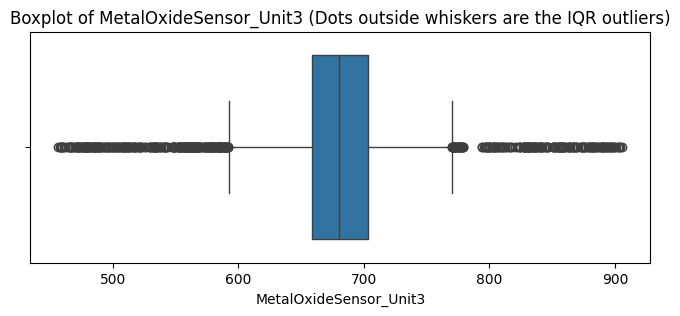

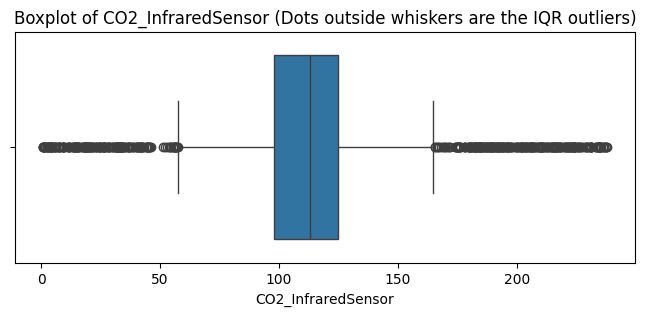

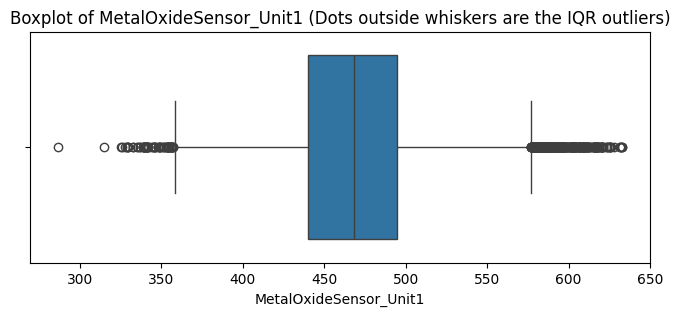

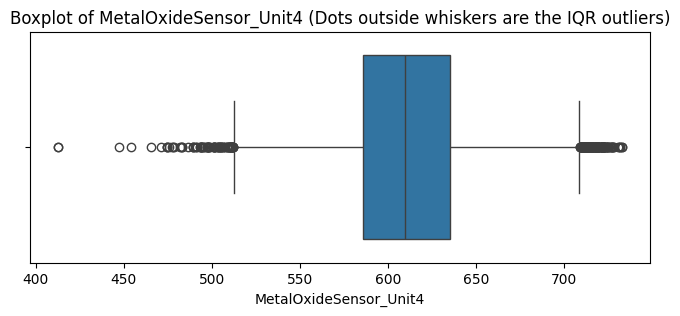

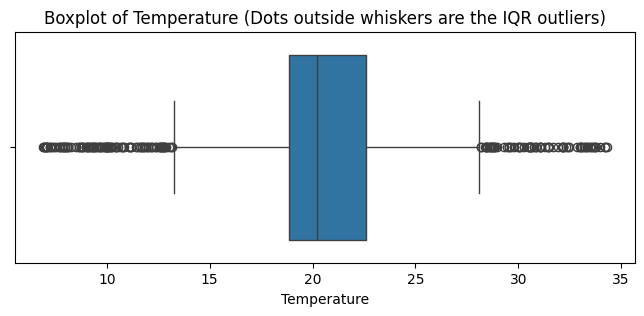

In [150]:
import seaborn as sns
import matplotlib.pyplot as plt

# Change column name to whatever showed the highest outlier count
top_outlier_col = iqr_summary.sort_values(by='Outlier Count', ascending=False).index[0]
for x in range(5):
    outlier_col = iqr_summary.sort_values(by='Outlier Count', ascending=False).index[x]
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df_clean[outlier_col])
    plt.title(f"Boxplot of {outlier_col} (Dots outside whiskers are the IQR outliers)")
    plt.show()

True Outliers vs. Heavy Tails

the 'outliers' are natural and are intense spikes that happened naturally / caused by something

In [ ]:

df_legend.to_csv('df_legend.csv', index=False)

df_clean.to_csv('df_clean.csv', index=False)